# UC1 -- Seasonal Baseline Detector (V1)

**Method.** For each minute t with bucket b = (hour, is_weekend), compute
median and MAD of same-bucket raw minute values from the preceding
WINDOW_DAYS days. Flag when the robust z-score exceeds the calibrated
threshold k.

```
robust_z(t) = (x_t - median[bucket(t), last N days]) / (1.4826 * MAD + eps)
flag(t)     = robust_z(t) > k
```

**Calibration recipe.** k is derived (not configured) by picking the
quantile of robust_z on the benign pool that yields the target
per-minute false-positive rate. The benign pool is "all minutes outside
any labeled event window with a valid score". Same recipe is used by
the ensemble notebook and the v1-vs-v2 comparison notebook.

**Why this is additive to EMA / Z-Score / IQR.** The other three detectors
all use short rolling windows (minutes). They cannot distinguish "high
traffic at 3 a.m." from "high traffic at 10 a.m.". A seasonal baseline
encodes the day-of-week x time-of-day expectation, so business-hours
ramps do not register while genuine off-hours bursts do.

**Pipeline.**
1. Load raw request records from `./data/nasa.csv`.
2. Aggregate to per-minute request counts (zero-fill missing minutes).
3. Assign (hour_of_day, is_weekend) bucket to each minute.
4. Rolling same-bucket median + MAD over WINDOW_DAYS prior days.
5. Calibrate k on benign minutes at the target FPR.
6. Flag minutes with robust_z > k.
7. Evaluate event coverage on real events; check Perseid hit rate as control.

**Warmup.** Per bucket the detector needs MIN_SAMPLES (default 15) raw
same-bucket minutes before it can score. With 48 buckets and 60 same-bucket
minutes per day, every bucket reaches MIN_SAMPLES well within the first
day. Final scored coverage is typically >= 99%.

**Status.** V1 has been superseded by V2 in the production seasonal slot
(see `uc1_seasonal_v1_vs_v2.ipynb` for the head-to-head). This notebook
is preserved as a reference implementation.


In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- Config ----------------------------------------------------------
WINDOW_DAYS  = 21          # rolling baseline window length (days)
MIN_SAMPLES  = 15          # min same-bucket raw minutes required to score
TARGET_FPR   = 0.005       # per-minute FPR target for k calibration
EPS          = 1e-6        # MAD floor (avoid div-by-zero on flat hours)

# Paths
LOG_FILE     = Path("./data/nasa.csv")
OUT_DIR      = Path("./outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Column name in the raw log CSV. ADJUST if your schema differs.
TS_COL       = "time"
# If timestamps are epoch seconds rather than datetime strings, set True.
TS_IS_EPOCH  = True

pd.set_option("display.max_columns", 50)
np.random.seed(42)


## 1. Load raw NASA HTTP logs

One row = one HTTP request. We only need the timestamp; other columns (host, url, status, bytes) are ignored for UC1 since we are detecting volumetric spikes, not content anomalies.

In [2]:
# Peek at the file to confirm column names
pd.read_csv(LOG_FILE, nrows=3)


,Unnamed: 0,host,time,method,url,response,bytes
0,0,***.novo.dk,805465029,GET,/ksc.html,200,7067
1,1,***.novo.dk,805465031,GET,/images/ksclogo-medium.gif,200,5866
2,2,***.novo.dk,805465051,GET,/images/MOSAIC-logosmall.gif,200,363


In [3]:
raw = pd.read_csv(LOG_FILE, usecols=[TS_COL])
print(f"Raw rows: {len(raw):,}")
raw.head()


Raw rows: 2,965,561


,time
0,805465029
1,805465031
2,805465051
3,805465053
4,805465054


In [4]:
# Parse timestamps
if TS_IS_EPOCH:
    raw["ts"] = pd.to_datetime(raw[TS_COL], unit="s", errors="coerce")
else:
    raw["ts"] = pd.to_datetime(raw[TS_COL], errors="coerce")

bad = raw["ts"].isna().sum()
if bad:
    print(f"Dropping {bad:,} rows with unparseable timestamps")
    raw = raw.dropna(subset=["ts"])

raw = raw.sort_values("ts").reset_index(drop=True)
print(f"Time range:     {raw['ts'].min()}  to  {raw['ts'].max()}")
print(f"Total requests: {len(raw):,}")


Time range:     1995-07-01 04:00:01  to  1995-09-01 03:59:53
Total requests: 2,965,561


## 2. Aggregate to per-minute request counts

`resample('1min').size()` bins requests by minute and returns 0 for minutes with no traffic. Zero-fill is critical for off-hours buckets where the baseline must see zeros, not missing values.

In [5]:
df = (raw.set_index("ts")
         .resample("1min").size()
         .rename("value")
         .reset_index()
         .rename(columns={"ts": "timestamp"}))

print(f"Per-minute rows:      {len(df):,}")
print(f"Zero-traffic minutes: {(df['value'] == 0).sum():,} "
      f"({(df['value'] == 0).mean():.1%})")
print(f"Max req/min:          {df['value'].max():,}")
print(f"Median req/min:       {df['value'].median():.1f}")
df.head()


Per-minute rows:      89,280
Zero-traffic minutes: 8,027 (9.0%)
Max req/min:          385
Median req/min:       28.0


,timestamp,value
0,1995-07-01 04:00:00,39
1,1995-07-01 04:01:00,55
2,1995-07-01 04:02:00,44
3,1995-07-01 04:03:00,60
4,1995-07-01 04:04:00,62


## 3. Inspect diurnal and weekly structure

Before committing to (hour, is_weekend) as the bucket key, verify the structure exists. If hourly profiles look flat, bucketing is pointless. If weekday and weekend look identical, collapse to hour-only.

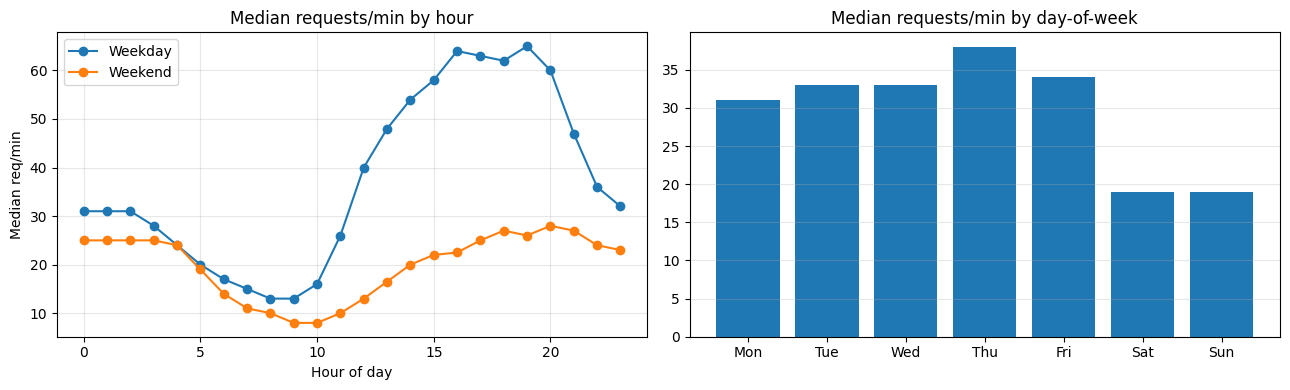

In [6]:
df["hour"]       = df["timestamp"].dt.hour
df["dow"]        = df["timestamp"].dt.dayofweek
df["is_weekend"] = df["dow"] >= 5

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for is_we, label in [(False, "Weekday"), (True, "Weekend")]:
    prof = (df[df["is_weekend"] == is_we]
            .groupby("hour")["value"]
            .median())
    axes[0].plot(prof.index, prof.values, marker="o", label=label)
axes[0].set_title("Median requests/min by hour")
axes[0].set_xlabel("Hour of day"); axes[0].set_ylabel("Median req/min")
axes[0].legend(); axes[0].grid(alpha=0.3)

dow_prof = df.groupby("dow")["value"].median()
axes[1].bar(dow_prof.index, dow_prof.values)
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])
axes[1].set_title("Median requests/min by day-of-week")
axes[1].grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()


## 4. Compute rolling seasonal baseline

For each minute t, baseline = median + MAD over same-bucket samples in the preceding WINDOW_DAYS days. Strictly causal: the point being scored is never in its own baseline.

In [7]:
def compute_seasonal_baseline_v1(df, window_days=WINDOW_DAYS, min_samples=MIN_SAMPLES):
    """V1 seasonal detector: rolling per-minute median + MAD over same-bucket history.

    For each minute t with bucket b, baseline = median and scale = MAD over
    same-bucket raw minute values in the preceding window_days. Robust z is
    (x - median) / (1.4826 * MAD + EPS). Strictly causal (the point being
    scored is never in its own baseline). Two-pointer per-bucket scan, O(N).

    Returns a copy of df with columns added:
      bucket           : (hour * 2 + is_weekend), 48 unique values
      baseline_median  : same-bucket median over window_days history
      baseline_mad     : same-bucket MAD    over window_days history
      robust_z         : (value - baseline_median) / (1.4826 * MAD + EPS)

    Rows with fewer than min_samples of same-bucket history get NaN.
    """
    df = df.sort_values("timestamp").reset_index(drop=True).copy()
    df["hour"]       = df["timestamp"].dt.hour.astype(np.int8)
    df["is_weekend"] = (df["timestamp"].dt.dayofweek >= 5).astype(np.int8)
    df["bucket"]     = (df["hour"].astype(np.int16) * 2
                        + df["is_weekend"]).astype(np.int16)

    window = pd.Timedelta(days=window_days)
    med_out = np.full(len(df), np.nan)
    mad_out = np.full(len(df), np.nan)

    for _, grp in df.groupby("bucket", sort=False):
        idx  = grp.index.to_numpy()
        ts   = grp["timestamp"].to_numpy()
        vals = grp["value"].to_numpy(dtype=np.float64)
        left = 0
        for right in range(len(grp)):
            t_left_bound = ts[right] - window
            while ts[left] < t_left_bound:
                left += 1
            window_vals = vals[left:right]    # strictly before current point
            if len(window_vals) >= min_samples:
                med = np.median(window_vals)
                med_out[idx[right]] = med
                mad_out[idx[right]] = np.median(np.abs(window_vals - med))

    df["baseline_median"] = med_out
    df["baseline_mad"]    = mad_out
    df["robust_z"] = (df["value"] - df["baseline_median"]) / (
        1.4826 * df["baseline_mad"] + EPS
    )
    return df

df = compute_seasonal_baseline_v1(df)
covered = df["baseline_median"].notna().mean()
print(f"Scored coverage: {covered:.1%} (rest are warmup minutes with insufficient history)")
df[["timestamp", "value", "bucket", "baseline_median", "baseline_mad", "robust_z"]].head(10)


Scored coverage: 99.2% (rest are warmup minutes with insufficient history)


,timestamp,value,bucket,baseline_median,baseline_mad,robust_z
0,1995-07-01 04:00:00,39,9,NaN,NaN,NaN
1,1995-07-01 04:01:00,55,9,NaN,NaN,NaN
2,1995-07-01 04:02:00,44,9,NaN,NaN,NaN
3,1995-07-01 04:03:00,60,9,NaN,NaN,NaN
4,1995-07-01 04:04:00,62,9,NaN,NaN,NaN
5,1995-07-01 04:05:00,42,9,NaN,NaN,NaN
6,1995-07-01 04:06:00,48,9,NaN,NaN,NaN
7,1995-07-01 04:07:00,60,9,NaN,NaN,NaN
8,1995-07-01 04:08:00,39,9,NaN,NaN,NaN
9,1995-07-01 04:09:00,37,9,NaN,NaN,NaN


## 5. Ground truth -- inline NASA mission events

**Two event classes.**

- **Real events** (STS missions): expected to drive elevated traffic on
  NASA's web presence. These are the positives for event-coverage scoring.
- **Control event** (Perseid meteor shower peak): the meteor shower is a
  pop-astronomy story but does not have a clear NASA-website signal. It
  is included here as a control: if Perseid hit rate is close to the
  benign FPR, the detector treats it as noise (which is what the literature
  expects). If Perseid hit rate is much higher, the detector is more
  sensitive than calibrated for, and that should be visible.

Times are UTC (matching the NASA log timestamps).


In [8]:
EVENTS = pd.DataFrame([
    ("STS-71 landing (Atlantis/Mir)", "1995-07-07 08:00", "1995-07-07 18:00", "real"),
    ("STS-70 launch (Discovery)",     "1995-07-13 10:00", "1995-07-13 20:00", "real"),
    ("STS-70 landing (Discovery)",    "1995-07-22 08:00", "1995-07-22 18:00", "real"),
    ("Perseid meteor shower peak",    "1995-08-12 00:00", "1995-08-13 23:59", "control"),
], columns=["name", "start", "end", "class"])
EVENTS["start"] = pd.to_datetime(EVENTS["start"])
EVENTS["end"]   = pd.to_datetime(EVENTS["end"])

REAL_EVENTS    = EVENTS[EVENTS["class"] == "real"].reset_index(drop=True)
CONTROL_EVENTS = EVENTS[EVENTS["class"] == "control"].reset_index(drop=True)

def label_from_events(timestamps, events):
    y  = np.zeros(len(timestamps), dtype=bool)
    ts = timestamps.to_numpy()
    for _, e in events.iterrows():
        y |= (ts >= np.datetime64(e["start"])) & (ts <= np.datetime64(e["end"]))
    return y

df["in_real_event"]    = label_from_events(df["timestamp"], REAL_EVENTS)
df["in_control_event"] = label_from_events(df["timestamp"], CONTROL_EVENTS)
df["in_any_event"]     = df["in_real_event"] | df["in_control_event"]
df["scored"]           = df["robust_z"].notna()

print(f"Real-event minutes:    {df['in_real_event'].sum():,}")
print(f"Control-event minutes: {df['in_control_event'].sum():,}")
print(f"Scored minutes:        {df['scored'].sum():,} ({df['scored'].mean():.1%})")
EVENTS


Real-event minutes:    1,803
Control-event minutes: 2,880
Scored minutes:        88,560 (99.2%)


,name,start,end,class
0,STS-71 landing (Atlantis/Mir),1995-07-07 08:00:00,1995-07-07 18:00:00,real
1,STS-70 launch (Discovery),1995-07-13 10:00:00,1995-07-13 20:00:00,real
2,STS-70 landing (Discovery),1995-07-22 08:00:00,1995-07-22 18:00:00,real
3,Perseid meteor shower peak,1995-08-12 00:00:00,1995-08-13 23:59:00,control


## 6. Threshold calibration

Pick k such that exactly TARGET_FPR of the benign pool is flagged. The
benign pool is `scored & ~in_any_event` (all valid minutes outside any
event window, real or control).

This is by-construction: at the calibrated k, the achieved FPR on the
benign pool equals TARGET_FPR by definition of the quantile. The metric
that actually matters for the thesis is event coverage, reported below.


In [9]:
benign_mask = df["scored"] & ~df["in_any_event"]
benign_scores = df.loc[benign_mask, "robust_z"].to_numpy()
print(f"Benign pool size: {benign_mask.sum():,}")

K_CALIBRATED = float(np.quantile(benign_scores, 1.0 - TARGET_FPR))
df["flag_seasonal"] = (df["robust_z"] > K_CALIBRATED).fillna(False)

achieved_fpr = float((benign_scores > K_CALIBRATED).mean())
print(f"Calibrated k:         {K_CALIBRATED:.4f}")
print(f"Achieved benign FPR:  {achieved_fpr:.4f}  (target {TARGET_FPR:.4f})")


Benign pool size: 83,877
Calibrated k:         3.2452
Achieved benign FPR:  0.0050  (target 0.0050)


## 7. Evaluation

**Event coverage**: how many of the real events have at least one flagged
minute inside their window? This is the thesis-relevant metric.

**Per-event minute counts**: how many minutes inside each event window
were flagged. A 5/600 minute hit on a 10-hour event still counts as
"covered" but is much weaker than 200/600.

**Perseid hit rate** (control): should sit close to the benign FPR. If
it does, the detector is treating Perseid as noise -- which is the
expected behavior.


In [10]:
ts = df["timestamp"].to_numpy()
flag = df["flag_seasonal"].to_numpy()

rows = []
for _, e in REAL_EVENTS.iterrows():
    in_evt = (ts >= np.datetime64(e["start"])) & (ts <= np.datetime64(e["end"]))
    rows.append({
        "event":            e["name"],
        "minutes_in_event": int(in_evt.sum()),
        "flagged_minutes":  int((flag & in_evt).sum()),
        "covered":          bool((flag & in_evt).any()),
    })
event_table = pd.DataFrame(rows)
events_covered = int(event_table["covered"].sum())
print(f"Real events covered: {events_covered}/{len(REAL_EVENTS)}")
print()
print(event_table.to_string(index=False))

print()
ctrl = df["in_control_event"].to_numpy()
ctrl_hit = (flag & ctrl).sum() / max(ctrl.sum(), 1)
print(f"Control (Perseid) hit rate: {ctrl_hit:.4f}  "
      f"(benign FPR for comparison: {achieved_fpr:.4f})")


Real events covered: 3/3

                        event  minutes_in_event  flagged_minutes  covered
STS-71 landing (Atlantis/Mir)               601                8     True
    STS-70 launch (Discovery)               601              222     True
   STS-70 landing (Discovery)               601                4     True

Control (Perseid) hit rate: 0.0087  (benign FPR for comparison: 0.0050)


## 8. Threshold sweep -- pick a different operating point if desired

Seasonal is meant to be the precision-leaning vote in the 4-detector ensemble. The calibrated k from section 6 is the production default; the sweep is here so the trade-off curve is visible if you want to argue for a different operating point (higher k = fewer false positives but maybe missed events).

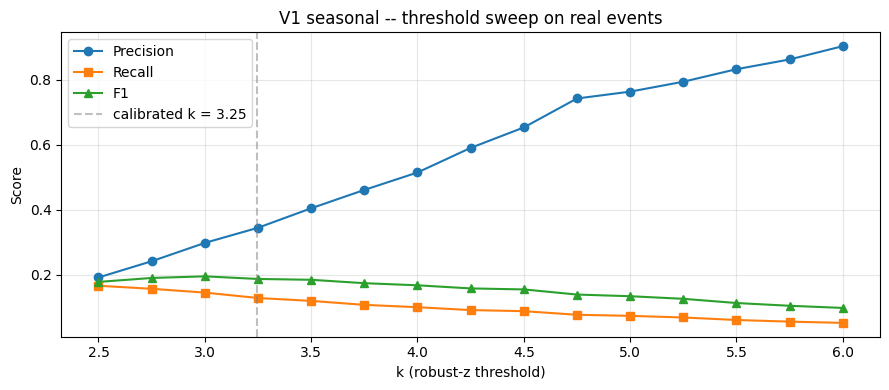

,k,precision,recall,f1,flagged
0,2.50,0.191299,0.165835,0.177659,0.017649
1,2.75,0.241232,0.156406,0.189771,0.013200
2,3.00,0.297605,0.144759,0.194776,0.009903
3,3.25,0.344262,0.128120,0.186742,0.007577
4,3.50,0.404135,0.119246,0.184154,0.006007
5,3.75,0.460621,0.107044,0.173717,0.004731
6,4.00,0.514286,0.099834,0.167209,0.003952
7,4.25,0.589928,0.090960,0.157617,0.003139
8,4.50,0.652893,0.087632,0.154523,0.002733
9,4.75,0.741935,0.076539,0.138763,0.002100


In [11]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Real-events as positives, evaluated on scored minutes only.
mask = df["scored"].to_numpy()
y_true = df["in_real_event"].to_numpy()[mask]
scores = df["robust_z"].to_numpy()[mask]

ks = np.arange(2.5, 6.01, 0.25)
rows = []
for k in ks:
    yp = scores > k
    rows.append({
        "k":         round(float(k), 2),
        "precision": precision_score(y_true, yp, zero_division=0),
        "recall":    recall_score(y_true, yp, zero_division=0),
        "f1":        f1_score(y_true, yp, zero_division=0),
        "flagged":   yp.mean(),
    })
sweep = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(sweep["k"], sweep["precision"], marker="o", label="Precision")
ax.plot(sweep["k"], sweep["recall"],    marker="s", label="Recall")
ax.plot(sweep["k"], sweep["f1"],        marker="^", label="F1")
ax.axvline(K_CALIBRATED, color="grey", linestyle="--", alpha=0.5,
           label=f"calibrated k = {K_CALIBRATED:.2f}")
ax.set_xlabel("k (robust-z threshold)"); ax.set_ylabel("Score")
ax.set_title("V1 seasonal -- threshold sweep on real events")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

sweep


## 9. Timeline visualization

Shows the per-minute traffic, the rolling baseline, and the calibrated band, with flagged minutes highlighted and event windows shaded.

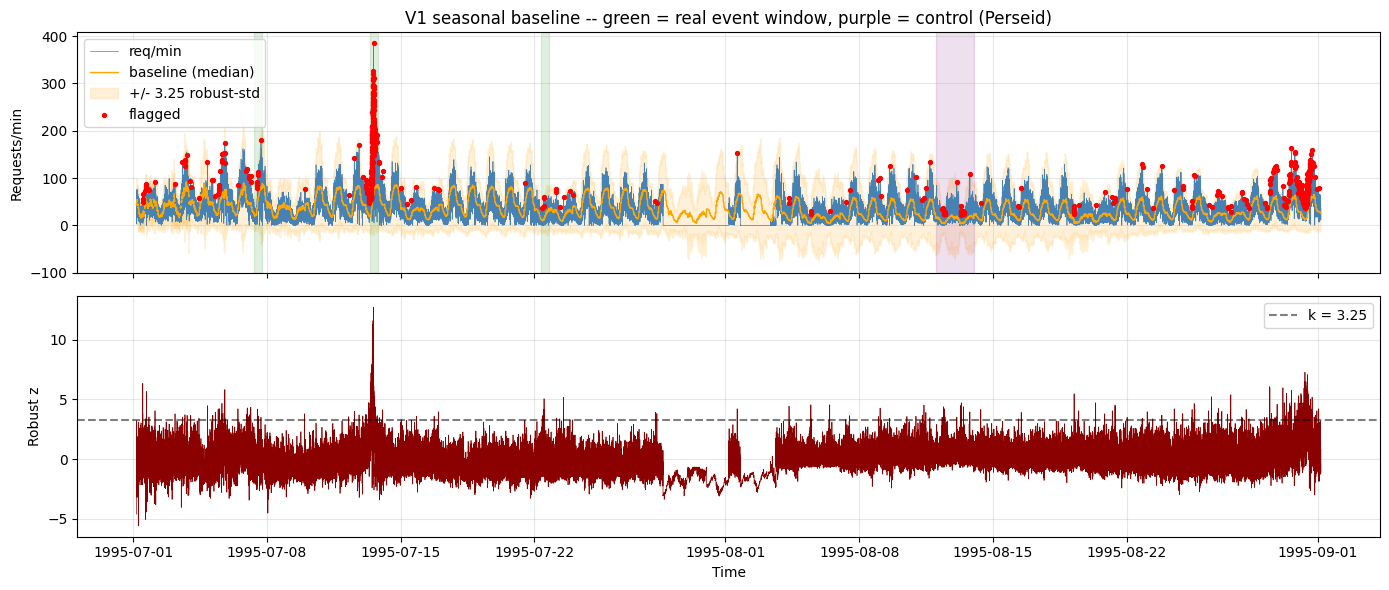

In [12]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

ax1.plot(df["timestamp"], df["value"], lw=0.5, color="steelblue", label="req/min")
ax1.plot(df["timestamp"], df["baseline_median"], lw=1.0, color="orange",
         label="baseline (median)")
ax1.fill_between(df["timestamp"],
                 df["baseline_median"] - K_CALIBRATED * 1.4826 * df["baseline_mad"],
                 df["baseline_median"] + K_CALIBRATED * 1.4826 * df["baseline_mad"],
                 alpha=0.15, color="orange",
                 label=f"+/- {K_CALIBRATED:.2f} robust-std")

flagged = df[df["flag_seasonal"]]
ax1.scatter(flagged["timestamp"], flagged["value"],
            color="red", s=8, zorder=5, label="flagged")

for _, e in EVENTS.iterrows():
    color = "green" if e["class"] == "real" else "purple"
    ax1.axvspan(e["start"], e["end"], alpha=0.12, color=color)

ax1.set_ylabel("Requests/min")
ax1.legend(loc="upper left"); ax1.grid(alpha=0.3)
ax1.set_title("V1 seasonal baseline -- green = real event window, purple = control (Perseid)")

ax2.plot(df["timestamp"], df["robust_z"], lw=0.5, color="darkred")
ax2.axhline(K_CALIBRATED, color="black", linestyle="--", alpha=0.5,
            label=f"k = {K_CALIBRATED:.2f}")
ax2.set_ylabel("Robust z"); ax2.set_xlabel("Time")
ax2.grid(alpha=0.3); ax2.legend()
plt.tight_layout(); plt.show()


## 10. Export flags for ensemble integration

Output paths use a `_v1` suffix so this notebook does not silently overwrite the V2 standalone's exports.

In [13]:
flags_path  = OUT_DIR / "uc1_flags_seasonal_v1.csv"
config_path = OUT_DIR / "uc1_seasonal_v1_config.json"

(df[["timestamp", "robust_z", "flag_seasonal"]]
    .to_csv(flags_path, index=False))

config = {
    "detector_version":   "V1",
    "storage":            "rolling 21-day per-minute buffer (median + MAD per bucket)",
    "window_days":        WINDOW_DAYS,
    "min_samples":        MIN_SAMPLES,
    "target_fpr":         TARGET_FPR,
    "k_calibrated":       K_CALIBRATED,
    "achieved_benign_fpr": achieved_fpr,
    "events_covered":     events_covered,
    "events_total":       len(REAL_EVENTS),
    "perseid_hit_rate":   float(ctrl_hit),
    "bucket_spec":        "hour_of_day x is_weekend (48 buckets)",
    "stats":              "median + 1.4826 * MAD (robust z)",
    "events":             [{"name": r["name"], "start": str(r["start"]),
                            "end": str(r["end"]), "class": r["class"]}
                           for _, r in EVENTS.iterrows()],
}
with open(config_path, "w") as f:
    json.dump(config, f, indent=2)

print(f"Wrote {flags_path}")
print(f"Wrote {config_path}")


Wrote outputs\uc1_flags_seasonal_v1.csv
Wrote outputs\uc1_seasonal_v1_config.json
